In [1]:
import re
from collections import Counter

from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option('display.max_colwidth', None)

In [2]:
corpus_data = load_dataset('allenai/scifact', 'corpus')
claims_data = load_dataset('allenai/scifact', 'claims')

corpus_df = corpus_data['train'].to_pandas()
claims_df = claims_data['train'].to_pandas()

corpus_OG = corpus_df.copy()
claims_OG = claims_df.copy()

print(f"Corpus Shape: {corpus_df.shape}")
print(f"Claims Shape: {claims_df.shape}")

Corpus Shape: (5183, 4)
Claims Shape: (1261, 6)


In [3]:
# Changing IDs' data type to string to ensure we are on the same page
corpus_df['doc_id'] = corpus_df['doc_id'].astype(str).str.strip()
claims_df['evidence_doc_id'] = claims_df['evidence_doc_id'].astype(str).str.strip()

#converting corpus into a set ensuring uniqueness, using AND operator to ensure evidence_doc_id is not null and is to be found in corpus_df's doc ID
corpus_ids = set(corpus_df['doc_id'])
claims_df['evidence_doc_in_corpus'] = (claims_df['evidence_doc_id'].notna() & claims_df['evidence_doc_id'].isin(corpus_ids))

# Separating entries that connected with the corpus and those that didn't
claim_with_evidence = claims_df[claims_df['evidence_doc_in_corpus']].copy()
claim_without_evidence = claims_df[~claims_df['evidence_doc_in_corpus']].copy()

print(f"Claims with corpus evidence: {len(claim_with_evidence)}")
print(f"Claims without corpus evidence: {len(claim_without_evidence)}")

Claims with corpus evidence: 957
Claims without corpus evidence: 304


### Normalizing Text 

In [4]:
# Creating functions to normalize text but do not overprocess it.
def normalize_text(text: object) -> str:
    if pd.isna(text):
        return ''
    text = re.sub(r'\s+', ' ', str(text))
    return text.strip()

# Function to turn abstract into clean lists of sentences
def extract_clean_sentences(abstract_input: object) -> list[str]:
    if isinstance(abstract_input, (list, np.ndarray)):
        return [clean for sent in abstract_input if (clean := normalize_text(sent))]
    elif isinstance(abstract_input, str):
        cleaned = normalize_text(abstract_input)
        return [cleaned] if cleaned else []
    return []

In [5]:
# Clean corpus text & extract sentence structure
corpus_df['clean_title'] = corpus_df['title'].apply(normalize_text)
corpus_df['sentences'] = corpus_df['abstract'].apply(extract_clean_sentences)
corpus_df['sentence_count'] = corpus_df['sentences'].apply(len)
corpus_df['clean_abstract'] = corpus_df['sentences'].apply(lambda sents: ' '.join(sents))

# Clean claim text
claim_with_evidence['clean_claim'] = claim_with_evidence['claim'].apply(normalize_text)

corpus_df[['doc_id', 'sentence_count', 'sentences', 'clean_abstract']].head(2)

,doc_id,sentence_count,sentences,clean_abstract
0,4983,14,"[Alterations of the architecture of cerebral white matter in the developing human brain can affect cortical development and result in functional disabilities., A line scan diffusion-weighted magnetic resonance imaging (MRI) sequence with diffusion tensor analysis was applied to measure the apparent diffusion coefficient, to calculate relative anisotropy, and to delineate three-dimensional fiber architecture in cerebral white matter in preterm (n = 17) and full-term infants (n = 7)., To assess effects of prematurity on cerebral white matter development, early gestation preterm infants (n = 10) were studied a second time at term., In the central white matter the mean apparent diffusion coefficient at 28 wk was high, 1.8 microm2/ms, and decreased toward term to 1.2 microm2/ms., In the posterior limb of the internal capsule, the mean apparent diffusion coefficients at both times were similar (1.2 versus 1.1 microm2/ms)., Relative anisotropy was higher the closer birth was to term with greater absolute values in the internal capsule than in the central white matter., Preterm infants at term showed higher mean diffusion coefficients in the central white matter (1.4 +/-, 0.24 versus 1.15 +/-, 0.09 microm2/ms, p = 0.016) and lower relative anisotropy in both areas compared with full-term infants (white matter, 10.9 +/- 0.6 versus 22.9 +/-, 3.0%, p = 0.001; internal capsule, 24.0 +/-, 4.44 versus 33.1 +/-, 0.6% p = 0.006)., Nonmyelinated fibers in the corpus callosum were visible by diffusion tensor MRI as early as 28 wk; full-term and preterm infants at term showed marked differences in white matter fiber organization., The data indicate that quantitative assessment of water diffusion by diffusion tensor MRI provides insight into microstructural development in cerebral white matter in living infants.]","Alterations of the architecture of cerebral white matter in the developing human brain can affect cortical development and result in functional disabilities. A line scan diffusion-weighted magnetic resonance imaging (MRI) sequence with diffusion tensor analysis was applied to measure the apparent diffusion coefficient, to calculate relative anisotropy, and to delineate three-dimensional fiber architecture in cerebral white matter in preterm (n = 17) and full-term infants (n = 7). To assess effects of prematurity on cerebral white matter development, early gestation preterm infants (n = 10) were studied a second time at term. In the central white matter the mean apparent diffusion coefficient at 28 wk was high, 1.8 microm2/ms, and decreased toward term to 1.2 microm2/ms. In the posterior limb of the internal capsule, the mean apparent diffusion coefficients at both times were similar (1.2 versus 1.1 microm2/ms). Relative anisotropy was higher the closer birth was to term with greater absolute values in the internal capsule than in the central white matter. Preterm infants at term showed higher mean diffusion coefficients in the central white matter (1.4 +/- 0.24 versus 1.15 +/- 0.09 microm2/ms, p = 0.016) and lower relative anisotropy in both areas compared with full-term infants (white matter, 10.9 +/- 0.6 versus 22.9 +/- 3.0%, p = 0.001; internal capsule, 24.0 +/- 4.44 versus 33.1 +/- 0.6% p = 0.006). Nonmyelinated fibers in the corpus callosum were visible by diffusion tensor MRI as early as 28 wk; full-term and preterm infants at term showed marked differences in white matter fiber organization. The data indicate that quantitative assessment of water diffusion by diffusion tensor MRI provides insight into microstructural development in cerebral white matter in living infants."
1,5836,8,"[Myelodysplastic syndromes (MDS) are age-dependent stem cell malignancies that share biological features of activated adaptive immune response and ineffective hematopoiesis., Here we report that myeloid-derived suppressor cells (MDSC), which are classically linked to immunosuppression, inflam

In [6]:
# Statical Analysis on word spread in abstract and claims
corpus_df['abstract_word_count'] = corpus_df['clean_abstract'].apply(lambda x: len(x.split()))
claim_with_evidence['claim_word_count'] = claim_with_evidence['clean_claim'].apply(lambda x: len(x.split()))

print(f"Abstract Words - Mean: {corpus_df['abstract_word_count'].mean():.2f}, Median: {corpus_df['abstract_word_count'].median():.2f}")
print(f"Claim Words    - Mean: {claim_with_evidence['claim_word_count'].mean():.2f}, Median: {claim_with_evidence['claim_word_count'].median():.2f}")
print(f"Sentence Count Summary:\n{corpus_df['sentence_count'].describe()}")
print(f"\nDocuments with 0 sentences: {(corpus_df['sentence_count'] == 0).sum()}")

Abstract Words - Mean: 201.81, Median: 192.00
Claim Words    - Mean: 12.19, Median: 11.00
Sentence Count Summary:
count    5183.000000
mean        8.865908
std         8.017250
min         3.000000
25%         6.000000
50%         8.000000
75%        11.000000
max       367.000000
Name: sentence_count, dtype: float64

Documents with 0 sentences: 0


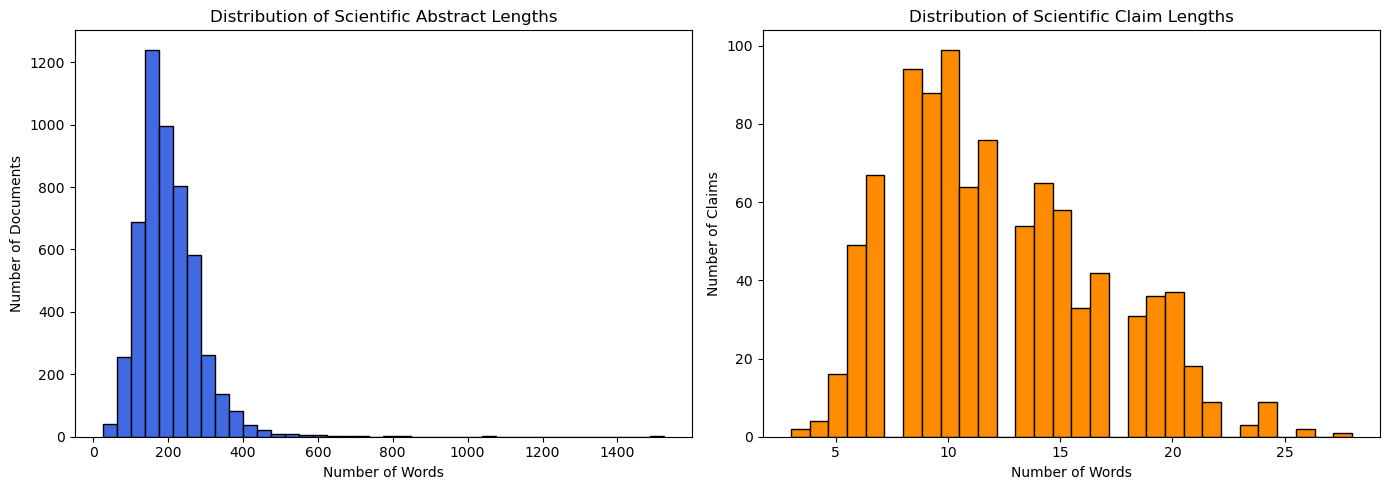

In [7]:
# Visualization of word distribution in Abstract and Claim
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(corpus_df['abstract_word_count'], bins=40, color='royalblue', edgecolor='black')
axes[0].set_title('Distribution of Scientific Abstract Lengths')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Number of Documents')

axes[1].hist(claim_with_evidence['claim_word_count'], bins=30, color='darkorange', edgecolor='black')
axes[1].set_title('Distribution of Scientific Claim Lengths')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Number of Claims')

plt.tight_layout()
plt.show()

In [8]:
sentence_records = [
    {'doc_id': doc_id, 'sentence_id': idx, 'sentence': sent}
    for doc_id, sents in zip(corpus_df['doc_id'], corpus_df['sentences'])
    for idx, sent in enumerate(sents)
]

sentence_df = pd.DataFrame(sentence_records)

print(f"Total sentence units: {len(sentence_df)}")
print(f"Total unique documents in sentence corpus: {sentence_df['doc_id'].nunique()}")
sentence_df.head(5)

Total sentence units: 45952
Total unique documents in sentence corpus: 5183


,doc_id,sentence_id,sentence
0,4983,0,Alterations of the architecture of cerebral white matter in the developing human brain can affect cortical development and result in functional disabilities.
1,4983,1,"A line scan diffusion-weighted magnetic resonance imaging (MRI) sequence with diffusion tensor analysis was applied to measure the apparent diffusion coefficient, to calculate relative anisotropy, and to delineate three-dimensional fiber architecture in cerebral white matter in preterm (n = 17) and full-term infants (n = 7)."
2,4983,2,"To assess effects of prematurity on cerebral white matter development, early gestation preterm infants (n = 10) were studied a second time at term."
3,4983,3,"In the central white matter the mean apparent diffusion coefficient at 28 wk was high, 1.8 microm2/ms, and decreased toward term to 1.2 microm2/ms."
4,4983,4,"In the posterior limb of the internal capsule, the mean apparent diffusion coefficients at both times were similar (1.2 versus 1.1 microm2/ms)."


In [9]:
claim_evidence_df = (
    claim_with_evidence[['id', 'clean_claim', 'evidence_doc_id', 'evidence_label', 'evidence_sentences']]
    .rename(columns={'id': 'claim_id'})
    .merge(
        corpus_df[['doc_id', 'clean_title', 'clean_abstract', 'sentences']],
        left_on='evidence_doc_id',
        right_on='doc_id',
        how='left'
    )
)

print(f"Total claims with evidence: {len(claim_evidence_df)}")
print(f"Successfully matched to corpus document: {claim_evidence_df['doc_id'].notna().sum()}")
claim_evidence_df.head(3)

Total claims with evidence: 957
Successfully matched to corpus document: 957


,claim_id,clean_claim,evidence_doc_id,evidence_label,evidence_sentences,doc_id,clean_title,clean_abstract,sentences
0,2,1 in 5 million in UK have abnormal PrP positivity.,13734012,CONTRADICT,[4],13734012,Prevalent abnormal prion protein in human appendixes after bovine spongiform encephalopathy epizootic: large scale survey,"OBJECTIVES To carry out a further survey of archived appendix samples to understand better the differences between existing estimates of the prevalence of subclinical infection with prions after the bovine spongiform encephalopathy epizootic and to see whether a broader birth cohort was affected, and to understand better the implications for the management of blood and blood products and for the handling of surgical instruments. DESIGN Irreversibly unlinked and anonymised large scale survey of archived appendix samples. SETTING Archived appendix samples from the pathology departments of 41 UK hospitals participating in the earlier survey, and additional hospitals in regions with lower levels of participation in that survey. SAMPLE 32,441 archived appendix samples fixed in formalin and embedded in paraffin and tested for the presence of abnormal prion protein (PrP). RESULTS Of the 32,441 appendix samples 16 were positive for abnormal PrP, indicating an overall prevalence of 493 per million population (95% confidence interval 282 to 801 per million). The prevalence in those born in 1941-60 (733 per million, 269 to 1596 per million) did not differ significantly from those born between 1961 and 1985 (412 per million, 198 to 758 per million) and was similar in both sexes and across the three broad geographical areas sampled. Genetic testing of the positive specimens for the genotype at PRNP codon 129 revealed a high proportion that were valine homozygous compared with the frequency in the normal population, and in stark contrast with confirmed clinical cases of vCJD, all of which were methionine homozygous at PRNP codon 129. CONCLUSIONS This study corroborates previous studies and suggests a high prevalence of infection with abnormal PrP, indicating vCJD carrier status in the population compared with the 177 vCJD cases to date. These findings have important implications for the management of blood and blood products and for the handling of surgical instruments.","[OBJECTIVES To carry out a further survey of archived appendix samples to understand better the differences between existing estimates of the prevalence of subclinical infection with prions after the bovine spongiform encephalopathy epizootic and to see whether a broader birth cohort was affected, and to understand better the implications for the management of blood and blood products and for the handling of surgical instruments., DESIGN Irreversibly unlinked and anonymised large scale survey of archived appendix samples., SETTING Archived appendix samples from the pathology departments of 41 UK hospitals participating in the earlier survey, and additional hospitals in regions with lower levels of participation in that survey., SAMPLE 32,441 archived appendix samples fixed in formalin and embedded in paraffin and tested for the presence of abnormal prion protein (PrP)., RESULTS Of the 32,441 appendix samples 16 were positive for abnormal PrP, indicating an overall prevalence of 493 per million population (95% confidence interval 282 to 801 per million)., The prevalence in those born in 1941-60 (733 per million, 269 to 1596 per million) did not differ significantly from those born between 1961 and 1985 (412 per million, 198 to 758 per million) and was similar in both sexes and across the three broad geographical areas sampled., Genetic testing of the positive specimens for the genotype at PRNP codon 129 revealed a high proportion that were valine homozygous compared with the frequency in the normal population, and in stark contrast with confirmed clinical cases of vCJD, all of which were methionine homozygous at PRNP codon 129., CONCLUSIONS This study c

In [10]:
def extract_evidence_text(sentences, indices):
    """Maps index numbers to raw sentence strings safely."""
    if not isinstance(sentences, list) or not isinstance(indices, list):
        return []
    total = len(sentences)
    return [sentences[i] for i in indices if isinstance(i, int) and 0 <= i < total]

claim_evidence_df['evidence_text'] = [
    extract_evidence_text(sents, idxs)
    for sents, idxs in zip(claim_evidence_df['sentences'], claim_evidence_df['evidence_sentences'])
]

valid_bounds = all(
    len(extracted) == len(idxs) if isinstance(idxs, list) else True
    for extracted, idxs in zip(claim_evidence_df['evidence_text'], claim_evidence_df['evidence_sentences'])
)
print(f"All evidence sentence indices are valid and within bounds: {valid_bounds}")

sample = claim_evidence_df.iloc[5]
print("\n--- SAMPLE CLAIM WITH EXTRACTED EVIDENCE ---")
print(f"Claim ID       : {sample['claim_id']}")
print(f"Claim Text     : {sample['clean_claim']}")
print(f"Label          : {sample['evidence_label']}")
print(f"Evidence Doc ID: {sample['evidence_doc_id']}")
print(f"Evidence Indices: {sample['evidence_sentences']}")
print(f"Evidence Text  : {sample['evidence_text']}")

All evidence sentence indices are valid and within bounds: True

--- SAMPLE CLAIM WITH EXTRACTED EVIDENCE ---
Claim ID       : 28
Claim Text     : A T helper 2 cell (Th2) environment impedes disease development in patients with systemic lupus erythematosus (SLE).
Label          : CONTRADICT
Evidence Doc ID: 12670680
Evidence Indices: [1]
Evidence Text  : []


In [11]:
claims_df['clean_claim'] = claims_df['claim'].apply(normalize_text)

corpus_clean = corpus_df[['doc_id', 'clean_title', 'clean_abstract', 'sentences', 'sentence_count']].copy()
claims_clean = claims_df[['id', 'clean_claim', 'evidence_doc_id', 'evidence_label', 'evidence_sentences', 'evidence_doc_in_corpus']].copy()

print("PIPELINE SUMMARY — PREPROCESSING COMPLETE")
print(f"Corpus documents           : {len(corpus_clean):,}")
print(f"Total claims               : {len(claims_clean):,}")
print(f"Claims with evidence (eval): {len(claim_evidence_df):,}")
print(f"Claims without evidence    : {len(claim_without_evidence):,}")
print(f"Total sentence units       : {len(sentence_df):,}")
print(f"Duplicate doc_ids          : {corpus_clean['doc_id'].duplicated().sum()}")


PIPELINE SUMMARY — PREPROCESSING COMPLETE
Corpus documents           : 5,183
Total claims               : 1,261
Claims with evidence (eval): 957
Claims without evidence    : 304
Total sentence units       : 45,952
Duplicate doc_ids          : 0
